# Third parameter estimation

## Unit system

The model flux equation is:

    v [mmol/(gDCW*h)] = kcat [mmol/(mg_prot*h)] * e [mg_prot/gDCW] * kappa * gamma

Enzyme concentrations (Data/important_proteins.csv) are in mg_prot/gDCW, so kcat
must be in mmol/(mg_prot*h). Table IV reports kcat both in s^-1 and converted:

    kcat [mmol/(mg_prot*h)] = kcat_s [1/s] * 3600 [s/h] / MW [g/mol]

(1/s * s/h / (g/mol) = mol/(g*h) = mmol/(mg*h), numerically identical.)
Example: FBA kcat = 10.33 s^-1, MW = 39147 g/mol -> 0.95 mmol/(mg_prot*h).
v_max_1 (PTS) is in mmol/(gDCW*h) directly (empirical formulation).

## Parameter split

Warm-started from the SECOND-estimation fitted theta
(results/second_estimation/theta_fitted.csv). Relative to the second estimation,
two parameters are moved from free to fixed (16 free / 21 fixed):

- Ks_f6p_3 (PFK)
- Ks_atp_3 (PFK)

This pair is the single exact (machine-precision) structural non-identifiability
direction found in the ROSM/SVD nullspace analysis of the second estimation's free
parameters (sigma_min = 3.22e-11; loadings +0.71 / -0.71 on exactly this pair, all
other free parameters ~0 -- see the "Structural identifiability" section of
plots_second_estimation.ipynb). Every other free parameter loads on softer,
non-exact directions further up the singular-value spectrum, so this pair is the
clearest, most acute candidate to resolve first.

Every fixed parameter (Ks_f6p_3/Ks_atp_3 included) is held at its second-estimation
value -- fitted if it was free in the second round, held value otherwise -- rather
than reset to raw literature. This mirrors what second_estimation.ipynb's code
actually does for all its fixed params, and is required here for feasibility:
resetting Ks_f6p_3/Ks_atp_3 to literature (0.013, 0.02 mM) while their correlated
partner kcat_f_3 stayed warm-started from a fit tuned assuming ~50-100x larger Km's
left IPOPT unable to satisfy the steady state (local infeasibility). Free parameters
warm-start from the second-estimation fitted value.


In [1]:
import sys
import os
import json
import pickle
import warnings
import datetime

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt

# warnings.filterwarnings("ignore")

_REPO_ROOT = os.path.abspath(os.path.dirname("__file__"))
sys.path.insert(0, os.path.join(_REPO_ROOT, "src"))

from kinetics_noor import ALL_PARAMS
from param_estimation_parmest import (
    GlycolysisParameterEstimator,
    available_conditions,
    check_solver,
    THETA_BOUNDS,
    ALL_PARAMS as ALL_PARAMS_est,
)

# Tunable globals
SEED = 0
# Metabolite-bounds modeling knob: log-space mean +/- N_STD*std (see
# utils.metabolite_bounds). Used by the comparable-footing sensitivity below --
# kept at 3 to match fixed_estimation/first_estimation/second_estimation, so
# that comparison stays valid. The fit's own bounds use a separate, hardcoded
# n_std=2 (see build-estimator), unchanged from second_estimation.
N_STD = 3
SIGMA_LOG10 = 0.5

_REPO_ROOT = os.path.abspath(".")  # notebook runs from repo root
RESULTS_DIR = os.path.join(_REPO_ROOT, "results", "third_estimation")
FIRST_ESTIMATION_DIR = os.path.join(_REPO_ROOT, "results", "first_estimation")
SECOND_ESTIMATION_DIR = os.path.join(_REPO_ROOT, "results", "second_estimation")
os.makedirs(RESULTS_DIR, exist_ok=True)

# All 22 experimental conditions from the Ishii dataset.
# To use a subset for faster prototyping, replace with e.g.:
#   CONDITIONS = ["KO02", "KO03", "KO05"]
# Deterministic: all conditions, sorted -- shared with fixed_estimation so the
# sensitivity analysis is on the same footing (order-independent for the fit).
CONDITIONS = sorted(available_conditions())
print("ALL_PARAMS count:", len(ALL_PARAMS))
print("CONDITIONS (%d):" % len(CONDITIONS), CONDITIONS)

ALL_PARAMS count: 37
CONDITIONS (22): ['KO02', 'KO03', 'KO04', 'KO05', 'KO07', 'KO08', 'KO10', 'KO11', 'KO12', 'KO13', 'KO14', 'KO15', 'KO16', 'KO17', 'KO18', 'KO19', 'KO20', 'KO21', 'KO22', 'KO23', 'KO24', 'RF03']


## Parameter catalogue and Bar-Even sampler


Central-CE medians: kcat = 79 s^-1 (vs 13.7 global); kcat/Km = 410
mM^-1 s^-1 (= 4.1e5 M^-1 s^-1; vs 1.25e5 global). Implied Km median = 0.19 mM.
Each quantity is drawn from a lognormal whose width comes from a 95% interval
[lo, hi]: sigma = (ln(hi) - ln(lo)) / (2 * 1.96). 

In [2]:
from sample_parameters import (
    TABLE_IV_THETA,
    LITERATURE_PARAMS,
    SAMPLED_KCAT,
    SAMPLED_KM,
    SAMPLED_PARAMS,
)


In [3]:
from sample_parameters import (
    ENZYME_MW_KDA,
    kcat_convert,
    KCAT_MEDIAN_S,
    KCAT_RANGE_S,
    KCATKM_MEDIAN,
    KCATKM_RANGE,
    KM_MEDIAN_MM,
    KM_RANGE_MM,
    LINKED_KMS,
    DIRECT_KMS,
    build_theta_init,
    load_theta_init,
    build_theta_sources_df,
)

# use the theta_init as the estimation from the first estimation

parameter_status = {
    # PTS
    'v_max_1': 'free',
    'Ka1_1': 'fixed',
    'Ka2_1': 'free',
    'Ka3_1': 'free',
    'K_g6p_1': 'free',
    
    # PGI
    'Ks_g6p_pgi': 'free',
    'Kp_f6p_pgi': 'fixed',
    'kcat_f_2': 'free',
    
    # PFK
    'Ks_f6p_3': 'fixed',
    'Ks_atp_3': 'fixed',
    'Kp_fbp_3': 'fixed',
    'Kp_adp_3': 'fixed',
    'kcat_f_3': 'free',
    
    # FBA
    'Ks_fbp_4': 'free',
    'Kp_g3p_4': 'fixed',
    'Kp_dhap_4': 'fixed',
    'kcat_f_4': 'free',
    
    # TPI
    'kcat_f_5': 'free',
    'Ks_dhap_5': 'fixed',
    'Kp_g3p_5': 'fixed',
    
    # GAP
    'kcat_f_6': 'free',
    'Ks_g3p_6': 'fixed',
    'Ks_pi_6': 'fixed',
    'Ks_nad_6': 'fixed',
    'Kp_pgp_6': 'fixed',
    'Kp_nadh_6': 'fixed',
    
    # PGK
    'kcat_f_7': 'free',
    'Ks_pgp_7': 'fixed',
    'Ks_adp_7': 'fixed',
    'Ks_3pg_7': 'fixed',
    'Ks_atp_7': 'fixed',
    
    # GPM
    'kcat_f_8': 'free',
    'Ks_3pg_8': 'free',
    'Ks_2pg_8': 'fixed',
    
    # ENO
    'kcat_f_9': 'free',
    'Ks_2pg_9': 'free',
    'Ks_pep_9': 'fixed',
}
theta_fitted_2 = pd.read_csv(os.path.join(SECOND_ESTIMATION_DIR, "theta_fitted.csv"), index_col=0)
theta_fitted_2.rename(columns={"value": "fitted_value"}, inplace=True)
literature_params = pd.read_csv(os.path.join(FIRST_ESTIMATION_DIR, "theta_init_sources.csv"), index_col=0)
theta_init_2 = pd.read_csv(os.path.join(SECOND_ESTIMATION_DIR, "theta_init_sources.csv"), index_col=0)
theta_init_2.rename(columns={"value": "initial_value"}, inplace=True)
theta_2 = pd.concat([theta_init_2, theta_fitted_2], axis=1)
theta_2
for index in theta_2.index:
    if np.isnan(theta_2.loc[index, "fitted_value"]) == True:
        theta_2.loc[index, "fitted_value"] = theta_2.loc[index, "initial_value"]
theta_third_est = pd.DataFrame(index=theta_2.index)
theta_third_est['value'] = theta_2['fitted_value']

for index in theta_third_est.index:

    theta_third_est.loc[index, 'status'] = parameter_status[index]
theta_third_est

,value,status
param,,
v_max_1,80.285242,free
Ka1_1,0.001709,fixed
Ka2_1,0.029715,free
Ka3_1,6.467003,free
K_g6p_1,11.242505,free
Ks_g6p_pgi,6.177563,free
Kp_f6p_pgi,10.053134,fixed
kcat_f_2,504.704481,free
Ks_f6p_3,0.662440,fixed


In [4]:

theta_third_est['type'] = None
theta_third_est['source'] = None
for idx in theta_third_est.index:
    theta_third_est.loc[idx, 'value'] = theta_2.loc[idx, 'fitted_value']
    theta_third_est.loc[idx, 'type'] = theta_third_est.loc[idx, 'status']
    if theta_third_est.loc[idx, 'status'] == 'fixed' and idx in LITERATURE_PARAMS:
        theta_third_est.loc[idx, 'source'] = 'Literature (held at 2nd-est value)'
    else:
        theta_third_est.loc[idx, 'source'] = 'Estimated'

## Build the estimator



In [5]:
from utils import metabolite_bounds

# Data-derived bounds (modeling choice) shared by the fit AND the post-fit
# sensitivity, so the sensitivity is evaluated at the true operating point.
# mode=(balanced, imbalanced): balanced (internal) use log_std for search room,
# imbalanced (cofactors) use data_range (+10% slack) to stay physiological.
# n_std=2 here is intentionally hardcoded (not the global N_STD), matching
# second_estimation.ipynb's fit bounds exactly; N_STD=3 is reserved for the
# comparable-footing sensitivity vs. fixed_estimation further below.
U_BOUNDS_DATA, X_BOUNDS_DATA = metabolite_bounds('Data', n_std=2,
                                                 mode=('log_std', 'data_range'),
                                                 slack=0.1)

# Per-parameter kinetic bounds, grounded in E. coli central-carbon biology:
#   Km / Ka / K binding constants (mM): [1e-3, 20] -- brackets the literature
#     Km's (0.01-1.03 mM, median 0.22) and the measured metabolite range
#     (0.002-2.48 mM) with headroom for weak binders.
#   kcat (mmol/mg_prot/h): [0.1, 1000] for the glycolytic enzymes (literature
#     0.95-42). TPI (kcat_f_5) is near the diffusion limit (literature 1201) so
#     it gets its own higher ceiling [50, 1e4].
#   v_max_1 (PTS, mmol/gDCW/h): [1, 100], a few-fold above the measured PTS flux
#     (literature 25.7).
v_max_min, v_max_max = [1, 100]
k_cat_min, k_cat_max = [0.1, 1000]
k_cat_fast_min, k_cat_fast_max = [50, 10000]
ks_min, ks_max = [1e-3, 20.0]
theta_bounds = {
    'v_max_1': [v_max_min, v_max_max],
    'Ka1_1': [ks_min, ks_max],
    'Ka2_1': [ks_min, ks_max],
    'Ka3_1': [ks_min, ks_max],
    'K_g6p_1': [ks_min, ks_max],
    'Ks_g6p_pgi': [ks_min, ks_max],
    'Kp_f6p_pgi': [ks_min, ks_max],
    'kcat_f_2': [k_cat_min, k_cat_max],
    'Ks_f6p_3': [ks_min, ks_max],
    'Ks_atp_3': [ks_min, ks_max],
    'Kp_fbp_3': [ks_min, ks_max],
    'Kp_adp_3': [ks_min, ks_max],
    'kcat_f_3': [k_cat_min, k_cat_max],
    'Ks_fbp_4': [ks_min, ks_max],
    'Kp_g3p_4': [ks_min, ks_max],
    'Kp_dhap_4': [ks_min, ks_max],
    'kcat_f_4': [k_cat_min, k_cat_max],
    'kcat_f_5': [k_cat_fast_min, k_cat_fast_max],
    'Ks_dhap_5': [ks_min, ks_max],
    'Kp_g3p_5': [ks_min, ks_max],
    'kcat_f_6': [k_cat_min, k_cat_max],
    'Ks_g3p_6': [ks_min, ks_max],
    'Ks_pi_6': [ks_min, ks_max],
    'Ks_nad_6': [ks_min, ks_max],
    'Kp_pgp_6': [ks_min, ks_max],
    'Kp_nadh_6': [ks_min, ks_max],
    'kcat_f_7': [k_cat_min, k_cat_max],
    'Ks_pgp_7': [ks_min, ks_max],
    'Ks_adp_7': [ks_min, ks_max],
    'Ks_3pg_7': [ks_min, ks_max],
    'Ks_atp_7': [ks_min, ks_max],
    'kcat_f_8': [k_cat_min, k_cat_max],
    'Ks_3pg_8': [ks_min, ks_max],
    'Ks_2pg_8': [ks_min, ks_max],
    'kcat_f_9': [k_cat_min, k_cat_max],
    'Ks_2pg_9': [ks_min, ks_max],
    'Ks_pep_9': [ks_min, ks_max]
}

# process fixed and free
free_params = [p for p, status in parameter_status.items() if status == 'free']
fixed_params = [p for p, status in parameter_status.items() if status == 'fixed']
est = GlycolysisParameterEstimator(
    conditions=CONDITIONS,
    theta_init=theta_third_est['value'].to_dict(), # warm start from the second estimation
    x_bounds=X_BOUNDS_DATA,
    u_bounds=U_BOUNDS_DATA,
    free_params=free_params,
    fixed_params=fixed_params,
    theta_bounds=theta_bounds,
)
print(est.summary())

GlycolysisParameterEstimator
  conditions       : 22
  free parameters  : 16 / 37
  fixed parameters : 21
  data points      : 301
  objective        : SSE_weighted
  imbalanced u_e   : free decision vars
  estimated        : False


## Pre-fit diagnostics (CasADi only, no ipopt required)

`predict()` solves the steady state at the initial parameters using CasADi and
returns a `Prediction` dataclass.  The RMSE values here are the baseline before
any fitting.

**Note:** if fluxes are off-scale relative to measurements, this is the expected
behavior when the sampled kcat values differ from the true values.  The estimator
will correct them during fitting.


In [6]:
pred0 = est.predict(theta=theta_third_est['value'].to_dict())
print("Pre-fit prediction summary:")
print(pred0.summary())
print("\nPer-output RMSE (sorted descending):")
print(pred0.per_output.sort_values(ascending=False).round(4).to_string())

Pre-fit prediction summary:
Prediction over 22 condition(s), 18 outputs (301 measured cells):
  RMSE met       = 0.2202 mM
  RMSE flux      = 1.208 mmol/gDCW/h
  RMSE data_norm = 1.195 (dimensionless, column-mean normalized)
  RMSE weighted  = 7.092 (sigma units; ~1 = at noise floor)
  worst-fit outputs: v_eno=2.33, v_pgk=2.09, v_gpmA=1.63

Per-output RMSE (sorted descending):
v_eno     2.3267
v_pgk     2.0853
v_gpmA    1.6323
v_pts     0.6827
C_g6p     0.3121
C_3pg     0.3005
v_pgi     0.2763
v_pfkB    0.2750
v_gapA    0.2254
C_dhap    0.1967
C_f6p     0.1528
v_fbaA    0.1444
v_tpiA    0.1444
C_fbp     0.1152
C_pep     0.0731


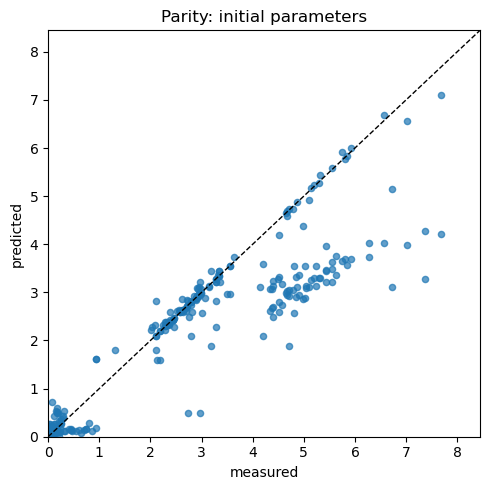

In [7]:
# Quick parity plot at initial parameters.
pv = pred0.predicted.to_numpy(dtype=float).ravel()
rv = pred0.real.to_numpy(dtype=float).ravel()
mask = ~(np.isnan(pv) | np.isnan(rv))
pv_m, rv_m = pv[mask], rv[mask]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rv_m, pv_m, s=20, alpha=0.7)
lim_lo = min(rv_m.min(), pv_m.min()) * 0.9
lim_hi = max(rv_m.max(), pv_m.max()) * 1.1
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=1)
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel("measured"); ax.set_ylabel("predicted")
ax.set_title("Parity: initial parameters")
fig.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, "parity_init.png"), dpi=100, bbox_inches="tight")
plt.show()


## Parameter estimation



In [8]:
theta_fitted = None
obj_value = float("nan")

# Solver options for ipopt. print_level is only used when verbose=True in
# multistart(); set verbose=False to silence per-restart ipopt output.
est.solver_options = {
    "print_level": 5,
    "linear_solver": "mumps",
    "nlp_scaling_method": "gradient-based",
    "max_iter": 8000,
    "acceptable_iter": 15,
    "acceptable_tol": 1e-5,
    "tol": 1e-6,
    "mu_strategy": "adaptive",
    "bound_push": 1e-8,
    "bound_frac": 1e-8,
    "warm_start_init_point": "yes",
}
est.pest = est._make_estimator()

# verbose=True prints ipopt output for every restart (useful for debugging).
# Set verbose=False for quiet runs (only the best result is printed below).
VERBOSE_MULTISTART = True

# For the THIRD estimation we have a fair warm start (the second-fit theta),
# so rand_guess_and_bound (samples between the current value and the bounds)
# exploits it, whereas strategy="rand" discards it.  Empirical check on the
# second estimation (6-condition subset): rand_guess_and_bound reached obj 9.85
# vs warm-start 11.32, while "rand" and "midpoint_guess_and_bound" only fell back
# to ~11.3.  NOTE: HCS mode (iterations=-1) requires strategy="rand"; not used here.
theta_series = est.multistart(
    strategy="rand_guess_and_bound",
    iterations = 20,
    seed=0,
    stopping_mass=0.02,
    stopping_delta=0.05,
    HCS_max_iterations=200,
    HCS_tolerance=0,
    suppress_unbounded_warning=True,
    verbose=VERBOSE_MULTISTART,
)

Ipopt 3.14.19: print_level=5
linear_solver=mumps
nlp_scaling_method=gradient-based
max_iter=8000
acceptable_iter=15
acceptable_tol=1e-05
tol=1e-06
mu_strategy=adaptive
bound_push=1e-08
bound_frac=1e-08
warm_start_init_point=yes


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     2486
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     2728

Total number of variables............................:      720
                     variables with only lower bounds: 

In [9]:
obj_value = theta_series['best_obj']
theta_fitted = theta_series['best_theta'].to_dict()
print("Done. Objective value:", round(obj_value, 4))
print(pd.Series(theta_fitted).round(5).to_frame("theta_fitted").T.to_string())

Done. Objective value: 88.7556
               v_max_1    Ka2_1     Ka3_1   K_g6p_1  Ks_g6p_pgi   kcat_f_2   kcat_f_3  Ks_fbp_4  kcat_f_4    kcat_f_5   kcat_f_6   kcat_f_7  kcat_f_8  Ks_3pg_8  kcat_f_9  Ks_2pg_9
theta_fitted  66.44597  0.08173  10.19854  10.92107     6.84594  521.96854  750.21776   0.00311   3.67006  2904.04004  417.63758  985.04256   908.761   2.18551   284.411   0.46674


## Post-fit matrices and diagnostics

Each block below wraps its API call in try/except so that a single failure
(e.g. covariance not available without a successful fit) does not abort the
remaining cells.  Results are saved to RESULTS_DIR regardless.


In [10]:
cov_df = None
corr_df = None
ci_df = None

cov_df = est.covariance('automatic_differentiation_kaug', step=0.00005)

corr = np.zeros(cov_df.shape)
for i in range(cov_df.shape[0]):
    for j in range(cov_df.shape[1]):
        if cov_df.iloc[i,i]*cov_df.iloc[j,j] > 0:
            corr[i,j] = cov_df.iloc[i,j]/np.sqrt(cov_df.iloc[i,i]*cov_df.iloc[j,j])
        else:
            corr[i,j] = 0.0
corr_df = pd.DataFrame(corr, index=cov_df.index, columns=cov_df.columns)
ci_df = est.confidence_intervals(alpha=0.05)
print("Covariance shape:", cov_df.shape)
print("Correlation shape:", corr_df.shape)
print("Confidence intervals (head):")
print(ci_df.head().round(4).to_string())

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:       47
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       49

Total number of variables............................:       16
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       16
                     variables with only upper bounds:        0
Total number of equality constraints.................:        9
Total number

In [11]:
fim_df = None

_theta_for_sens = theta_fitted if theta_fitted is not None else theta_third_est['value'].to_dict()

fim_df = est.fisher_information_matrix(theta=_theta_for_sens, free_only=True)
print("FIM shape:", fim_df.shape)
eigvals = np.sort(np.linalg.eigvalsh(fim_df.to_numpy(dtype=float)))[::-1]
print("FIM eigenvalues (top 10):", eigvals[:10].round(3))
print("FIM rank estimate (eigvals > 1e-10):",
        int(np.sum(eigvals > 1e-10)))

FIM shape: (16, 16)
FIM eigenvalues (top 10): [8.77719978e+06 3.72970965e+05 1.44014200e+03 1.52154000e+02
 1.03360000e+01 4.65400000e+00 5.55000000e-01 4.00000000e-03
 1.00000000e-03 0.00000000e+00]
FIM rank estimate (eigvals > 1e-10): 16


In [12]:
_theta_for_sens = theta_fitted if theta_fitted is not None else theta_third_est['value'].to_dict()
sens_dict = est.sensitivity_matrix(theta=_theta_for_sens, kind="both")
print("Sensitivity matrices computed for %d conditions." % len(sens_dict))
first_cond = next(iter(sens_dict))
print("  Shape for condition '%s':" % first_cond, sens_dict[first_cond].shape)

Sensitivity matrices computed for 22 conditions.
  Shape for condition 'KO02': (18, 37)


Post-fit prediction summary:
Prediction over 22 condition(s), 18 outputs (301 measured cells):
  RMSE met       = 0.2082 mM
  RMSE flux      = 1.208 mmol/gDCW/h
  RMSE data_norm = 1.215 (dimensionless, column-mean normalized)
  RMSE weighted  = 7.006 (sigma units; ~1 = at noise floor)
  worst-fit outputs: v_eno=2.33, v_pgk=2.09, v_gpmA=1.63

RMSE comparison:
             init  fitted
met        0.2202  0.2082
flux       1.2082  1.2082
data_norm  1.1951  1.2147
weighted   7.0919  7.0055


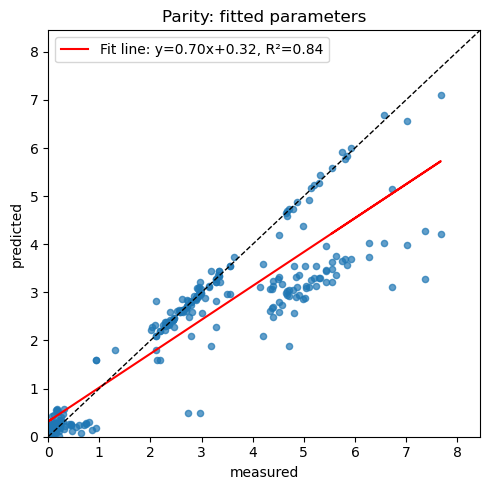

In [13]:
from scipy.stats import pearsonr
from scipy.stats import linregress
pred_fitted = None
rmse_fitted = None

pred_fitted = est.predict(theta=theta_fitted)
rmse_fitted = pred_fitted.rmse
print("Post-fit prediction summary:")
print(pred_fitted.summary())

# RMSE comparison table.
rmse_tbl = pd.DataFrame({
    "init": pred0.rmse,
    "fitted": rmse_fitted,
})
print("\nRMSE comparison:")
print(rmse_tbl.round(4).to_string())

fig, ax = plt.subplots(figsize=(5, 5))
pv = pred_fitted.predicted.to_numpy(dtype=float).ravel()
rv = pred_fitted.real.to_numpy(dtype=float).ravel()
mask = ~(np.isnan(pv) | np.isnan(rv))
pv_m, rv_m = pv[mask], rv[mask]
ax.scatter(rv_m, pv_m, s=20, alpha=0.7)
slope, intercept, r_value, p_value, std_err = linregress(rv_m, pv_m)
ax.plot(rv_m, slope * rv_m + intercept, color='red',
        label=f'Fit line: y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
ax.legend()
lim_lo = min(rv_m.min(), pv_m.min()) * 0.9
lim_hi = max(rv_m.max(), pv_m.max()) * 1.1
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=1)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel("measured")
ax.set_ylabel("predicted")
ax.set_title("Parity: fitted parameters")
fig.tight_layout()
plt.show()

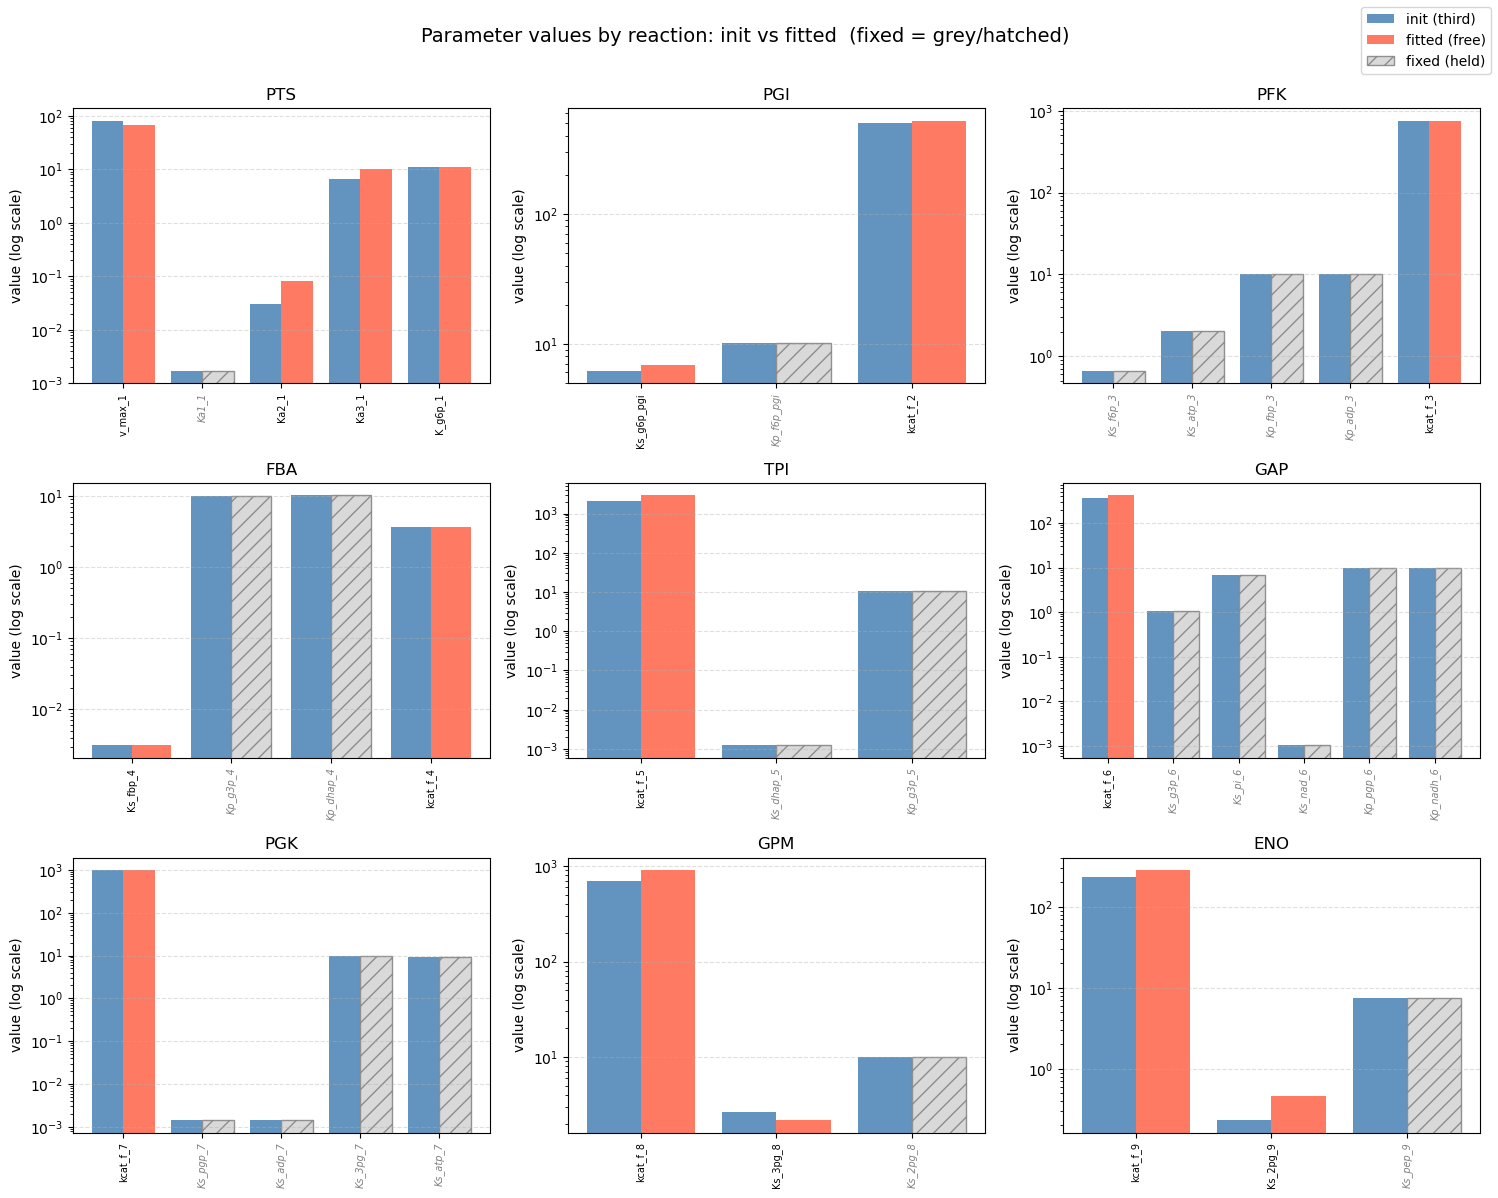

In [14]:
# Per-reaction parameter comparison: initial vs fitted (one panel per reaction).
# Fixed params (held during the third fit) are drawn grey + hatched, with greyed
# italic tick labels, so the free/fixed split is obvious at a glance.
from kinetics_noor import PARAM_RXN_MAP
from matplotlib.patches import Patch

reactions = list(PARAM_RXN_MAP.keys())
has_fitted = theta_fitted is not None
status = parameter_status
width = 0.4

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, rxn in zip(axes.ravel(), reactions):
    params = PARAM_RXN_MAP[rxn]
    x = np.arange(len(params))
    init_vals = [theta_third_est['value'][p] for p in params]

    ax.bar(x - width / 2, init_vals, width, label="init (third)",
           color="steelblue", alpha=0.85)

    if has_fitted:
        # theta_fitted only holds the FREE params (multistart best_theta).
        # For FIXED params the fitted value is the held value (they did not move),
        # so fall back to theta_third_est -> no KeyError on fixed params.
        fitted_vals = [theta_fitted.get(p, theta_third_est['value'][p])
                       for p in params]
        fitted_colors = ["lightgrey" if status[p] == "fixed" else "tomato"
                         for p in params]
        bars = ax.bar(x + width / 2, fitted_vals, width, color=fitted_colors,
                      alpha=0.85)
        for b, p in zip(bars, params):
            if status[p] == "fixed":
                b.set_hatch("//")
                b.set_edgecolor("grey")

    ax.set_yscale("log")
    ax.set_title(rxn.upper())
    ax.set_xticks(x)
    ax.set_xticklabels(params, rotation=90, fontsize=7)
    for tick, p in zip(ax.get_xticklabels(), params):
        if status[p] == "fixed":
            tick.set_color("grey")
            tick.set_style("italic")
    ax.set_ylabel("value (log scale)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

legend_handles = [
    Patch(facecolor="steelblue", alpha=0.85, label="init (third)"),
    Patch(facecolor="tomato", alpha=0.85, label="fitted (free)"),
    Patch(facecolor="lightgrey", edgecolor="grey", hatch="//", alpha=0.85,
          label="fixed (held)"),
]
fig.legend(handles=legend_handles, loc="upper right", fontsize=10)

suptitle = "Parameter values by reaction: init vs fitted  (fixed = grey/hatched)"
if not has_fitted:
    suptitle = "Parameter values by reaction: init only (fitted unavailable)"

fig.suptitle(suptitle, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])

fig_dir = os.path.join(RESULTS_DIR, "figures")
os.makedirs(fig_dir, exist_ok=True)
fig.savefig(os.path.join(fig_dir, "theta_by_reaction.png"),
            dpi=150, bbox_inches="tight")
plt.show()


In [15]:
struct_report = None

_theta_for_struct = theta_fitted if theta_fitted is not None else theta_third_est['value'].to_dict()
struct_report = est.structural_report(theta=_theta_for_struct, corr_threshold=0.9)
print("Structural report keys:", list(struct_report.keys()))
print("\nPer-condition:")
print(struct_report["per_condition"].round(2).to_string())
print("\nIdentifiability:")
print(struct_report["identifiability"].to_string())
print("\nPer-parameter (head):")
print(struct_report["per_parameter"].head(10).round(3).to_string())

Structural report keys: ['per_condition', 'identifiability', 'per_parameter']

Per-condition:
           ss_residual  rank_A        cond_A  n_bound_active  rank_G
condition                                                           
KO02              0.00       9  1.764459e+07               0       8
KO03              0.00       9  3.762374e+07               0       7
KO04              0.68       9  2.188167e+09               0       7
KO05              0.00       9  8.979921e+07               0       8
KO07              0.00       9  2.364082e+07               0       8
KO08              0.00       9  2.982572e+07               0       7
KO10              0.00       9  1.627531e+07               0       7
KO11              0.00       9  2.579926e+07               0       7
KO12              0.00       9  1.241487e+07               0       8
KO13              0.00       9  1.919181e+07               0       8
KO14              0.00       9  1.095166e+07               0       8
KO15     

## Save all artifacts to RESULTS_DIR


In [16]:
def save_matrices(
    results_dir,
    theta_init,
    theta_sources_df,
    pred0,
    theta_story=None,
    theta_fitted=None,
    pred_fitted=None,
    cov_df=None,
    corr_df=None,
    ci_df=None,
    fim_df=None,
    sens_dict=None,
    struct_report=None,
    obj_value=float("nan"),
    ipopt_available=False,
    seed=SEED,
    sigma_log10=SIGMA_LOG10,
    conditions=None,
    free_params=None,
):
    """
    Save all estimation artifacts to results_dir.
    Writes CSVs, JSON, pickle, and a manifest.
    """
    os.makedirs(results_dir, exist_ok=True)

    def _csv(df, name):
        if df is not None:
            df.to_csv(os.path.join(results_dir, name))
            print("  saved", name)

    # theta_init as a single-column CSV [value]
    ti_series = pd.Series(theta_init, name="value")
    ti_series.index.name = "param"
    _csv(ti_series.to_frame(), "theta_init.csv")

    # theta_init_sources: [param, value, source]
    _csv(theta_sources_df, "theta_init_sources.csv")

    # theta_fitted
    if theta_fitted is not None:
        tf_series = pd.Series(theta_fitted, name="value")
        tf_series.index.name = "param"
        _csv(tf_series.to_frame(), "theta_fitted.csv")

    # multistart story: per-restart runs table + global-search diagnostics
    if theta_story is not None:
        all_runs = theta_story.get("all_runs")
        if all_runs is not None:
            all_runs.to_csv(os.path.join(results_dir, "multistart_runs.csv"),
                            index=False)
            print("  saved multistart_runs.csv (%d runs)" % len(all_runs))

        story_summary = {
            "method": theta_story.get("method"),
            "best_obj": (None if not np.isfinite(theta_story.get("best_obj", float("nan")))
                         else float(theta_story["best_obj"])),
            "n_converged": theta_story.get("n_converged"),
            "obj_median": (None if not np.isfinite(theta_story.get("obj_median", float("nan")))
                           else float(theta_story["obj_median"])),
            "frac_within": (None if not np.isfinite(theta_story.get("frac_within", float("nan")))
                            else float(theta_story["frac_within"])),
        }
        with open(os.path.join(results_dir, "multistart_summary.json"), "w") as fh:
            json.dump(story_summary, fh, indent=2)
        print("  saved multistart_summary.json")

    # covariance / correlation / confidence intervals
    _csv(cov_df, "covariance.csv")
    _csv(corr_df, "correlation.csv")
    _csv(ci_df, "confidence_intervals.csv")
    _csv(fim_df, "fim.csv")

    # predictions
    if pred0 is not None:
        _csv(pred0.predicted, "predictions_init.csv")
        _csv(pred0.real, "real.csv")
        with open(os.path.join(results_dir, "rmse_init.json"), "w") as fh:
            json.dump({k: (None if not np.isfinite(v) else float(v))
                       for k, v in pred0.rmse.items()}, fh, indent=2)
        print("  saved rmse_init.json")

    if pred_fitted is not None:
        _csv(pred_fitted.predicted, "predictions_fitted.csv")
        with open(os.path.join(results_dir, "rmse_fitted.json"), "w") as fh:
            json.dump({k: (None if not np.isfinite(v) else float(v))
                       for k, v in pred_fitted.rmse.items()}, fh, indent=2)
        print("  saved rmse_fitted.json")

    # sensitivity matrices
    if sens_dict is not None:
        sens_path = os.path.join(results_dir, "sensitivity.pkl")
        with open(sens_path, "wb") as fh:
            pickle.dump(sens_dict, fh)
        print("  saved sensitivity.pkl (%d conditions)" % len(sens_dict))

        # also save per-condition CSVs for easy inspection
        sens_dir = os.path.join(results_dir, "sensitivity")
        os.makedirs(sens_dir, exist_ok=True)
        for cond, G_df in sens_dict.items():
            G_df.to_csv(os.path.join(sens_dir, "%s.csv" % cond))
        print("  saved sensitivity/ CSVs")

    # structural report
    if struct_report is not None:
        for key, df in struct_report.items():
            if isinstance(df, pd.DataFrame):
                fname = "structural_report_%s.csv" % key
                _csv(df, fname)

    # manifest
    manifest = {
        "seed": seed,
        "sigma_log10": sigma_log10,
        "conditions": conditions or [],
        "n_conditions": len(conditions) if conditions else 0,
        "n_measured": 14,
        "free_params": free_params or [],
        "n_free_params": len(free_params) if free_params else 0,
        "obj_value": None if not np.isfinite(obj_value) else float(obj_value),
        "ipopt_available": ipopt_available,
        "timestamp": datetime.datetime.utcnow().isoformat() + "Z",
    }
    with open(os.path.join(results_dir, "manifest.json"), "w") as fh:
        json.dump(manifest, fh, indent=2)
    print("  saved manifest.json")
    print("All artifacts saved to:", results_dir)


save_matrices(
    results_dir=RESULTS_DIR,
    theta_init=theta_third_est['value'].to_dict(),
    theta_sources_df=theta_third_est,
    pred0=pred0,
    theta_story=theta_series,
    theta_fitted=theta_fitted,
    pred_fitted=pred_fitted,
    cov_df=cov_df,
    corr_df=corr_df,
    ci_df=ci_df,
    fim_df=fim_df,
    sens_dict=sens_dict,
    struct_report=struct_report,
    obj_value=obj_value,
    seed=SEED,
    sigma_log10=SIGMA_LOG10,
    conditions=CONDITIONS,
    free_params=[p for p, s in parameter_status.items() if s == 'free'],
)

  saved theta_init.csv
  saved theta_init_sources.csv
  saved theta_fitted.csv
  saved multistart_runs.csv (2 runs)
  saved multistart_summary.json
  saved covariance.csv
  saved correlation.csv
  saved confidence_intervals.csv
  saved fim.csv
  saved predictions_init.csv
  saved real.csv
  saved rmse_init.json
  saved predictions_fitted.csv
  saved rmse_fitted.json
  saved sensitivity.pkl (22 conditions)
  saved sensitivity/ CSVs
  saved structural_report_per_condition.csv
  saved structural_report_identifiability.csv
  saved structural_report_per_parameter.csv
  saved manifest.json
All artifacts saved to: /Users/gabbi/Desktop/Repos/biosistemas/HybridKinetics-IIQ3733/results/third_estimation


/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_24732/3219915397.py:123: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.datetime.utcnow().isoformat() + "Z",


In [17]:
# Comparable sensitivity footing (shared with fixed_estimation)
# Overwrite the per-condition sensitivity CSVs and predictions_fitted.csv at the
# fitted theta using the SAME data-derived bounds + sorted conditions as
# fixed_estimation, so the two sensitivity heatmaps differ ONLY by theta. The
# parmest posterior covariance / CIs / fix-justification above are unaffected.
if theta_fitted is not None:
    from utils import build_analysis_model, save_per_condition_sensitivity

    _amodel, _aconds, _aenz, _aneed, _ameas = build_analysis_model('Data', n_std=N_STD)
    # solve_steady_state needs ALL 37 params; theta_fitted holds only the free
    # subset, so merge it over the full second-init vector (fixed params keep
    # their held values, free params take their fitted values).
    _theta_full = {**theta_third_est['value'].to_dict(), **theta_fitted}
    _pred_cmp, _real_cmp = save_per_condition_sensitivity(
        _amodel, _theta_full, _aconds, _aenz, _aneed, RESULTS_DIR, data_dir='Data')
    _pred_cmp.to_csv(os.path.join(RESULTS_DIR, 'predictions_fitted.csv'))
    print('Regenerated comparable sensitivity/ + predictions_fitted.csv at theta_fitted')
    print('  (data-derived bounds, %d sorted conditions).' % len(_aconds))
else:
    print('No theta_fitted (ipopt unavailable) -- comparable-footing step skipped.')


Regenerated comparable sensitivity/ + predictions_fitted.csv at theta_fitted
  (data-derived bounds, 22 sorted conditions).
